# U-Net Architecture Notes

## Overview

U-Net consists of two main parts:

1. **Contracting Path (Encoder)**
2. **Expansive Path (Decoder)**

The architecture follows an encoder-decoder design where the encoder captures context and the decoder reconstructs precise segmentation maps.

---

# 1. Contracting Path (Encoder)

The encoder is essentially a typical Convolutional Neural Network (CNN).

### Operations

- Convolution Layer
  - Kernel Size = `3 × 3`
  - Padding = `0` (Valid Convolution)

- Max Pooling
  - Kernel Size = `2 × 2`
  - Stride = `2`

### What happens at each level?

- Spatial Resolution ↓ (height and width decrease)
- Channel Dimension ↑ (typically doubled)

Example:

| Feature Map Size | Channels |
|------------------|-----------|
| 572 × 572 | 64 |
| 284 × 284 | 128 |
| 140 × 140 | 256 |
| 68 × 68 | 512 |
| 32 × 32 | 1024 |

### Intuition

As we go deeper:

- We lose spatial details.
- We gain higher-level semantic understanding.
- The network learns *what* objects are present.

---

# 2. Expansive Path (Decoder)

The decoder uses **Transposed Convolutions** to reconstruct the segmentation map.

### Operations

- Transposed Convolution
  - Kernel Size = `3 × 3`
  - Padding = `0`

### What happens at each level?

- Spatial Resolution ↑ (upsampling)
- Channel Dimension ↓ (typically halved)

Example:

| Feature Map Size | Channels |
|------------------|-----------|
| 32 × 32 | 1024 |
| 64 × 64 | 512 |
| 128 × 128 | 256 |
| 256 × 256 | 128 |
| 512 × 512 | 64 |

### Intuition

As we move upward:

- Recover lost spatial information.
- Generate pixel-level predictions.
- Learn *where* objects are located.

---

# Skip Connections

Encoder and decoder communicate through **Skip Connections**.

### Why are they needed?

The encoder contains high-resolution spatial information that gets lost during downsampling.

The decoder contains semantic information but lacks precise localization.

Skip connections combine:

- Encoder Features → Precise localization
- Decoder Features → High-level semantics

Result:

```text
High-Level Understanding
+
Precise Localization
=
Accurate Segmentation
```

---

# Cropping Before Concatenation

In the original U-Net paper:

```text
Padding = 0
```

Because valid convolutions shrink feature map dimensions after every convolution, the encoder feature maps become larger than the corresponding decoder feature maps.

Therefore, before concatenation:

1. Crop the encoder feature map.
2. Match its spatial dimensions with the decoder feature map.
3. Concatenate along the channel dimension.

```text
Encoder Feature Map
        ↓
      Crop
        ↓
Concatenate
        ↓
Decoder Feature Map
```

---

# Dimension Changes Summary

## Encoder

```text
Input
   ↓
Conv (3×3, padding=0)
   ↓
Conv (3×3, padding=0)
   ↓
MaxPool (2×2, stride=2)

Spatial Resolution ↓
Channels ↑
```

## Decoder

```text
Input
   ↓
Transposed Conv
   ↓
Concatenate Skip Connection
   ↓
Conv Layers

Spatial Resolution ↑
Channels ↓
```

---

# Key Takeaways

- Encoder downsamples spatial resolution.
- Encoder increases channel dimensions.
- Decoder upsamples spatial resolution.
- Decoder decreases channel dimensions.
- Skip connections transfer high-resolution information from encoder to decoder.
- Original U-Net uses valid convolutions (`padding=0`).
- Cropping is required before concatenating skip connections.
- U-Net combines semantic understanding and precise localization for segmentation tasks.

---

# Original U-Net Architecture

The original U-Net architecture diagram is attached below for reference.

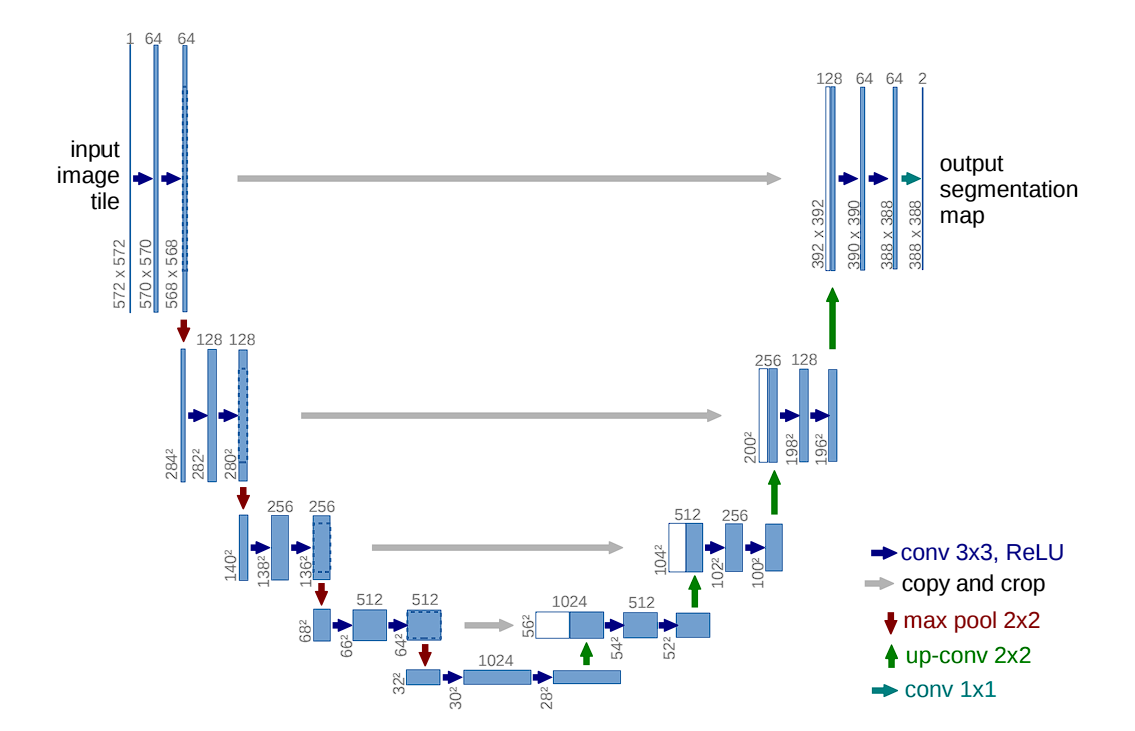

---

## ImageCropper Class

In [1]:
import torch
import torch.nn as nn
class ImageCropper(nn.Module):
    def __init__(self):
        super(ImageCropper, self).__init__()
    
    def forward(self, cropping_img: torch.Tensor, target_img: torch.Tensor):
        # Gather details for cropping the image
        _, _, H_c, W_c = cropping_img.shape # W_c: Width of cropping image, H_c: Height of cropping image
        _, _, H_t, W_t = target_img.shape # W_t: Width of target image, H_t: Height of target image

        # How much to crop
        H, W = (H_c - H_t) // 2, (W_c - W_t) // 2

        # Crop the img
        cropped_img = cropping_img[:, :, H: H_c - H, W: W_c - W]
        return cropped_img

---

## Skip Connections with Cropping

Since both my implementation and the original U-Net paper use `padding=0` (valid convolutions), the spatial dimensions shrink after each convolution. As a result, the encoder feature maps and decoder feature maps do not have matching spatial dimensions.

Before applying the skip connection, the encoder feature maps must be cropped to match the size of the corresponding decoder feature maps. Once the dimensions align, the cropped encoder features are concatenated with the decoder features along the channel dimension.

This allows the decoder to leverage the high-resolution spatial information learned by the encoder while reconstructing the segmentation output.

## Implementing Skip-Connections

In [2]:
class SkipConnection(nn.Module):
    def __init__(self, ImageCropper: ImageCropper):
        super(SkipConnection, self).__init__()
        self.img_cropper = ImageCropper()
    
    def forward(self, x: torch.tensor, y: torch.tensor):
        """
        Crops `x` to match the spatial dimensions of `y`, then concatenates the two tensors.
        Assumes that both tensors already have matching batch and channel dimensions

        Input: x: [B, C, H_x, W_x] and y: [B, C, H_y, W_y]
        Output: x: [B, 2C, H_y, W_y]
        """
        cropped_x = self.img_cropper(x, y)
        return torch.cat([cropped_x, y], dim = 1)

---

## Encoder Block

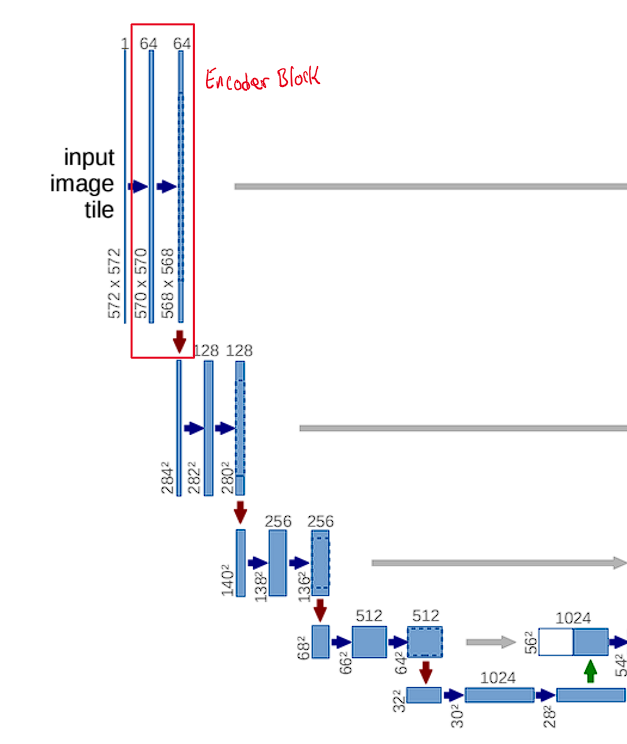

In [3]:
config = {
    # ---------------------- Encoder settings ---------------------------
    "kernel_size_E": 3,
    "padding_E": 0,
    "max_pool_stride": 2,
    "max_pool_kernel_size": 2,
    "n_layers_E": 4,
    "hidden_channels_E": 64, # used in 1st Layer of Encoder

    # ---------------------- Bottleneck settings ---------------------------
    "kernel_size_B": 3,
    "padding_B": 0,
    "stride_B": 1,
    "hidden_channels_B": 1024,
    "skip_connections_channel_B": 512,

    # ---------------------- Decoder settings ------------------------------
    "kernel_size_D": 3,
    "padding_D": 0,
    "up_conv_stride": 2,
    "up_conv_kernel_size": 2,
    "n_layers_D": 3, # because 1 layer is now a bottleneck
    "hidden_channels_D": 512, # used in 1st Layer of Decoder

    # ---------------------- Image settings ----------------------
    "img_channel_dim": 1,
    "img_H": 316,
    "img_W": 316,

    # ---------------------- Dataset path ------------------------
    "image_dir": "../data/oxford-iiit-pet/images/images",
    "mask_dir": "../data/oxford-iiit-pet/annotations/annotations/trimaps",

    # Image Cropper
    "ImageCropper": ImageCropper,

    # Image Segmentation settings
    "n_classes": 2,
    "segmentation_map_hidden_channels": 64,
    "segmentation_map_kernel_size": 1,
    "mask_img_H": 132,
    "mask_img_W": 132,

    # U-Net Model specific settings
    "in_channels_E": 1, # encoder layer in_channels
    "in_channels_B": 512, # bottelneck layer in_channels
    "in_channels_D": 1024, # decoder layer in_channels
    "in_channels_S": 128, # output segmentation layer in_channels

    # ---------------------- Model Training settings----------------------
    "batch_size": 1,
    "lr": 1e-4,
    "optimizer": "adam",
    "epochs": 80,
    "device": "cuda",

}

In [4]:
"""
This represents one Block of the Encoder

> In the original paper they have used a 3x3 convolution followed by another 3x3 convolution followed by a Max-polling layer
Paper name: U-Net: Convolutional Networks for Biomedical Image Segmentation
Paper Link: https://arxiv.org/pdf/1505.04597

So my Encoder Block will contain:
    1. 3x3 Conv (Padding = 0, Stride = 1, kernel_size = 3)
    2. 3x3 Conv (Padding = 0, Stride = 1, kernel_size = 3)
    3. Max pool Layer (Stride = 2, kernel_size = 2)
    4. Stores the `uncropped_intermediate_tensor` before max pooling. During decoding,
       these tensors are cropped as needed and used in the skip connections to
       concatenate encoder and decoder feature maps
"""
import torch
import torch.nn as nn

class EncoderBlock(nn.Module):
        def __init__(self, in_channels: int,
                hidden_channels: int,
                out_channels: int,
                kernel_size: int = config["kernel_size_E"],
                padding: int = config["padding_E"],
                debug: bool = False):
                super(EncoderBlock, self).__init__()
                self.relu = nn.ReLU()
                self.conv_1 = nn.Conv2d(in_channels = in_channels,
                        out_channels = hidden_channels,
                        kernel_size = kernel_size,
                        padding = padding)
                self.conv_2 = nn.Conv2d(in_channels = hidden_channels,
                        out_channels = out_channels,
                        kernel_size = kernel_size,
                        padding = padding)
                self.max_pool = nn.MaxPool2d(
                        stride = config["max_pool_stride"], # 2
                        kernel_size = config["max_pool_kernel_size"] # 2
                )
                self.debug = debug

        def forward(self, x: torch.Tensor):
            """
            Note: I am intentionally storing all intermediate encoder feature maps before applying max pooling.
            These feature maps will later be used for skip connections in the decoder.

            I also store them in a list because the required crop size is not known beforehand.
            The amount of cropping depends on the spatial dimensions of the corresponding decoder feature maps,
            which become available only during the decoding stage.
            """
            if self.debug: # Debug Mode is on, print the intermediate tensor shapes
                x = self.relu(self.conv_1(x))
                print(f"> Inside Encoder Block")
                print(f"x.shape = {x.shape}")
                print("-" * 70)
                uncropped_intermediate_tensor = self.relu(self.conv_2(x))
                print(f"uncropped_intermediate_tensor.shape = {uncropped_intermediate_tensor.shape}")
                print("-" * 70)
                y = self.max_pool(uncropped_intermediate_tensor)
                print(f"after_max_pool.shape = {y.shape}")
                print("-" * 70)
                return y, uncropped_intermediate_tensor
            else:
                x = self.relu(self.conv_1(x))
                uncropped_intermediate_tensor = self.relu(self.conv_2(x))
                y = self.max_pool(uncropped_intermediate_tensor)
                return y, uncropped_intermediate_tensor
                  
    

## Encoder

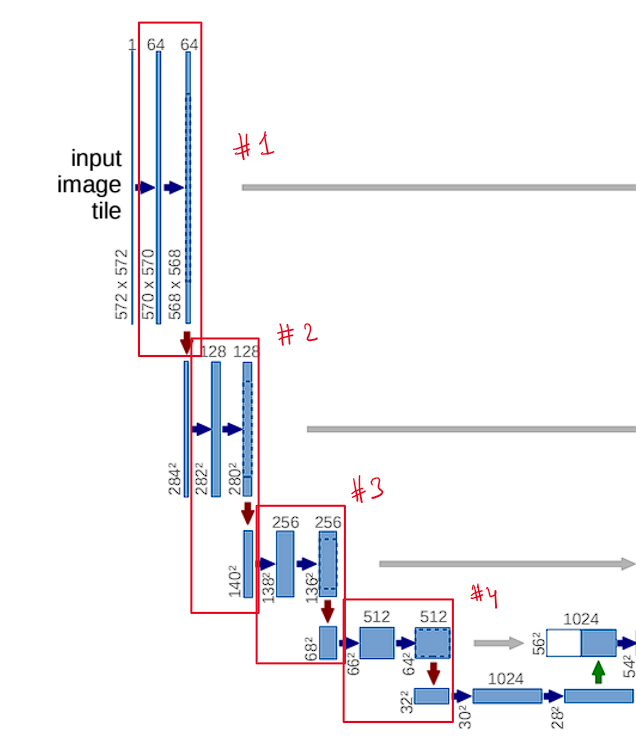

In [5]:
"""
This represents the entire Encoder Architecture discussed in the paper
I'll stack multiple encoder blocks to build the encoder pipeline

Paper name: U-Net: Convolutional Networks for Biomedical Image Segmentation
Paper Link: https://arxiv.org/pdf/1505.04597

So my Encoder Block will contain:
    1. 3x3 Conv
    2. 3x3 Conv
    3. Max pool Layer
    4. uncropped_intermediate_tensor before max pooling (used in skip-connection pipeline of U-Nets)
"""

class Encoder(nn.Module):
       def __init__(self, in_channels: int,
                kernel_size: int = config["kernel_size_E"],
                padding: int = config["padding_E"],
                n_layers: int = config["n_layers_E"],
                debug: bool = False):
              super(Encoder, self).__init__()
              self.in_channels = in_channels
              self.kernel_size = kernel_size
              self.padding = padding
              self.n_layers = n_layers
              self.debug = debug
       
              self.encoder_layers = [ # This is responsible to transform the image dim from 3 to 64
                     EncoderBlock(
                                   in_channels = self.in_channels,
                                   hidden_channels = config["hidden_channels_E"],
                                   out_channels = config["hidden_channels_E"],
                                   kernel_size = self.kernel_size,
                                   padding = self.padding,
                                   debug = self.debug
                     )
              ]

              # Build the Encoder
              prev_channel = config["hidden_channels_E"] # 3
              for _ in range(self.n_layers - 1):
                     self.encoder_layers.append(
                            EncoderBlock(
                                   in_channels = prev_channel,
                                   hidden_channels = prev_channel * 2,
                                   out_channels = prev_channel * 2,
                                   kernel_size = self.kernel_size,
                                   padding = self.padding,
                                   debug = self.debug
                            )
                     )
                     prev_channel *= 2
              self.encoder = nn.Sequential(*self.encoder_layers)
              
       def forward(self, x: torch.Tensor):
              """
              Save the encoder feature maps before max pooling reduces their spatial resolution.
              These high-resolution features will later be used in the skip connections.
              Before concatenation, they must be cropped to match the dimensions of the corresponding decoder feature maps.
              """
              self.uncropped_tensor_list = []
              for layer in self.encoder:
                     x, uncropped_tensor = layer(x)
                     self.uncropped_tensor_list.append(uncropped_tensor) # each tensor will have a different shape
              return x

---

## Bottleneck

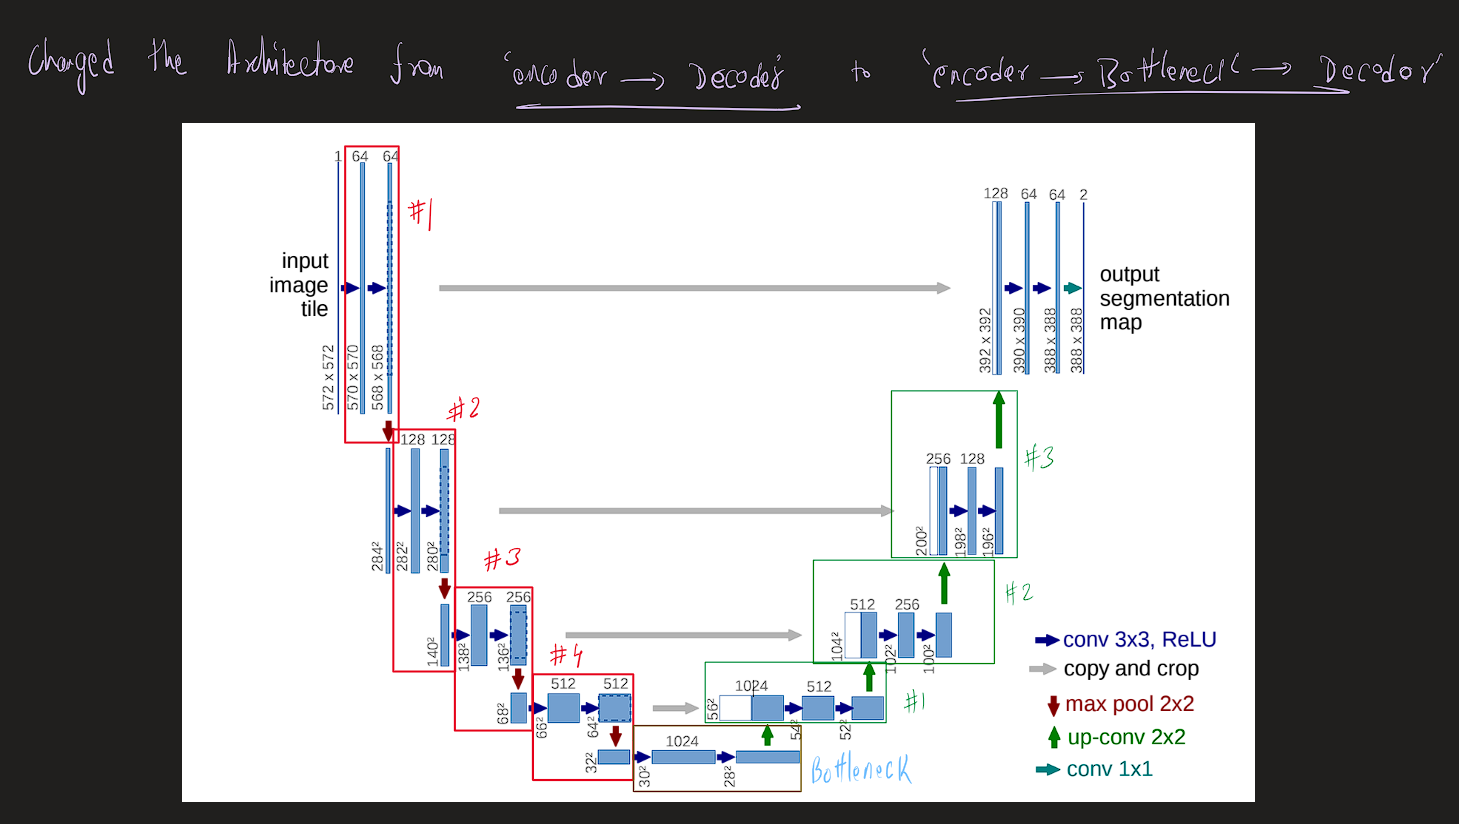

In [6]:
"""
Implements the bottleneck block of the U-Net architecture, which acts as a bridge between the Encoder and Decoder.

Given the encoder output:

enc_img = encoder(img)
enc_img.shape = [1, 512, 32, 32]

the bottleneck performs two convolutional operations followed by an up-convolution:

[1, 512, 32, 32]
        ↓
[1, 1024, 30, 30]
        ↓
[1, 1024, 28, 28]
        ↓
[1, 512, 64, 64]

Unlike the original U-Net architecture, the up-convolution is included within the bottleneck block.
The resulting feature map is then passed to the Decoder for the remaining upsampling and skip-connection operations.

Reference:
Paper: U-Net: Convolutional Networks for Biomedical Image Segmentation
Link: https://arxiv.org/pdf/1505.04597
"""

class Bottleneck(nn.Module):
    def __init__(self,
                in_channels: int,
                hidden_channels: int = config["hidden_channels_B"],
                out_channels: int = config["skip_connections_channel_B"],
                kernel_size: int = config["kernel_size_B"],
                padding: int = config["padding_B"],
                stride: int = config["stride_B"]):
        super(Bottleneck, self).__init__()
        conv_1 = nn.Conv2d(
            in_channels = in_channels, # 512
            out_channels = hidden_channels, # 1024
            kernel_size = kernel_size, # 3 x 3
            padding = padding, # 0
            stride = stride # 1
        )
        conv_2 = nn.Conv2d(
            in_channels = hidden_channels, # 1024
            out_channels = hidden_channels, # 1024
            kernel_size = kernel_size, # 3 x 3
            padding = padding, # 0
            stride = stride # 1
        )
        up_conv = nn.ConvTranspose2d(
                    in_channels = hidden_channels,
                    out_channels = out_channels,
                    kernel_size = config["up_conv_kernel_size"],
                    padding = config["padding_D"],
                    stride = config["up_conv_stride"],
        )
        self.bottleneck_block = nn.Sequential(
            conv_1, conv_2, up_conv
        )
    
    def forward(self, x: torch.Tensor):
        return self.bottleneck_block(x)

---

## Decoder Block

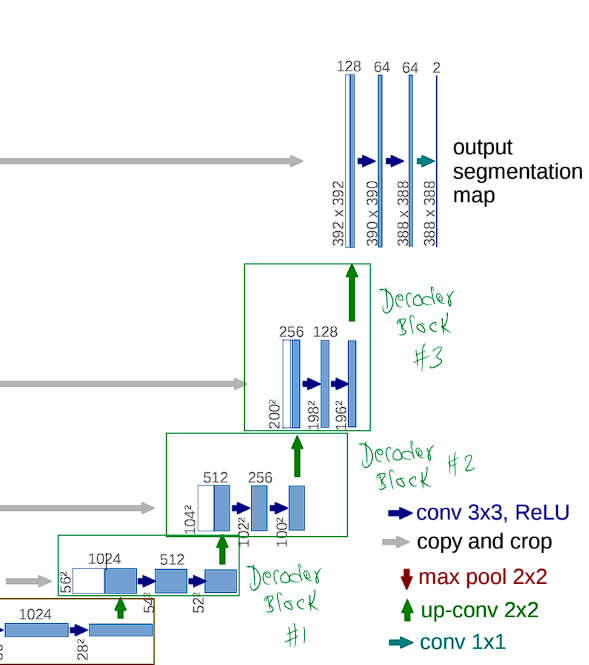

In [7]:
"""
This represents one Block of the Decoder

> In the original paper they have used a (3x3 convolution) followed by another (3x3 convolution) followed by a (2x2 Transposed Convolution)
Paper name: U-Net: Convolutional Networks for Biomedical Image Segmentation
Paper Link: https://arxiv.org/pdf/1505.04597

So my Decoder Block will contain:
    1. 3x3 Conv (out_channel = in_channel // 2, padding = 0, kernel_size = 3)
        [Reduces both the channel dim and spatial resolution]
    2. 3x3 Conv (out_channel = in_channel // 2, padding = 0, kernel_size = 3)
        [Reduces both the channel dim and spatial resolution]
    3. 2x2 up-conv (Transposed Convolution) [out_channel = in_channel // 2, kernel_size = 2, stride = 2]
        {Increases the spatial resolution, but decreases the channel_dim by half}
    4. Crops the encoder feature maps saved before max pooling and concatenates them
       with the corresponding decoder feature maps. Each crop-and-concatenate
       operation is performed before the first 3×3 convolution in the decoder block.
"""
class DecoderBlock(nn.Module):
    def __init__(self, in_channels: int,
                out_channels: int,
                hidden_channels_D: int = config["hidden_channels_D"],
                kernel_size_D: int = config["kernel_size_D"],
                padding_D: int = config["padding_D"],
                debug: bool = False):
              super(DecoderBlock, self).__init__()

              self.ImageCropper = config["ImageCropper"]
              self.skip_connection = SkipConnection(self.ImageCropper)

              self.relu = nn.ReLU()
            #   print("in_channels:", in_channels, type(in_channels))
            #   print("out_channels:", hidden_channels_D, type(hidden_channels_D))
            #   print("kernel_size:", kernel_size_D, type(kernel_size_D))
            #   print("padding:", padding_D, type(padding_D))

              # 3x3 convolution
              self.conv_1 = nn.Conv2d(
                  in_channels = in_channels,
                  out_channels = hidden_channels_D,
                  kernel_size = kernel_size_D, # 3
                  padding = padding_D # 0
              )
              # 3x3 convolution
              self.conv_2 = nn.Conv2d(
                  in_channels = hidden_channels_D,
                  out_channels = hidden_channels_D,
                  kernel_size = kernel_size_D, # 3
                  padding = padding_D # 0
              )
              self.up_conv = nn.ConvTranspose2d(
                  in_channels = hidden_channels_D,
                  out_channels = out_channels,
                  kernel_size = config["up_conv_kernel_size"], # 2
                  stride = config["up_conv_stride"] # 2
              )
              self.debug = debug

    def forward(self, x: torch.Tensor, uncropped_intermediate_tensor: torch.Tensor):
        if self.debug: # Debug Mode is on, print the intermediate tensor shapes
            print("-" * 60)
            print(f"x.shape = {x.shape}")
            print(f"uncropped_intermediate_tensor.shape = {uncropped_intermediate_tensor.shape}")
            x = self.skip_connection(uncropped_intermediate_tensor, x)
            print(f"x.shape after skip connections = {x.shape}")
            print("-" * 60)
            x = self.relu(self.conv_1(x))
            x = self.relu(self.conv_2(x))
            y = self.up_conv(x)
            return y
        else:
            x = self.skip_connection(uncropped_intermediate_tensor, x)
            x = self.relu(self.conv_1(x))
            x = self.relu(self.conv_2(x))
            y = self.up_conv(x)
            return y
              

## Decoder

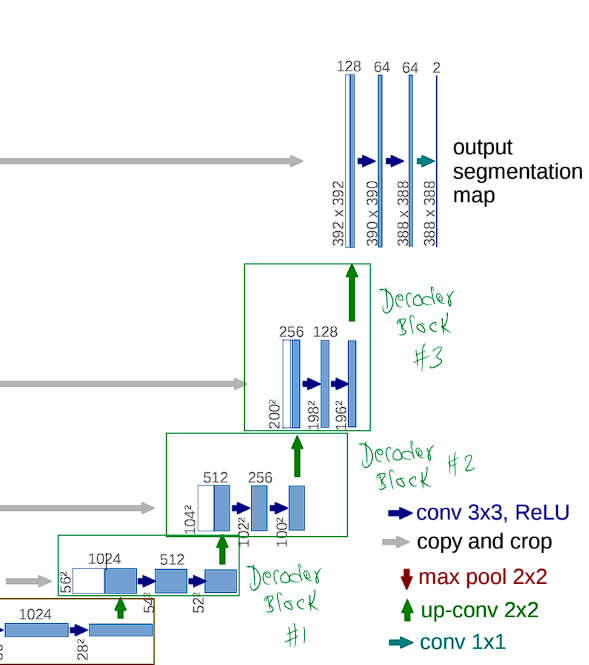

In [8]:
from typing import List
class Decoder(nn.Module):
       """
       Stacking Multiple DecoderBlocks to make decoder
       Each Decoder Block will reduce the channel_dim by half and progressevely increases the spatial resolution
       """
       def __init__(self, in_channels: int,
                kernel_size: int = config["kernel_size_D"],
                padding: int = config["padding_D"],
                n_layers: int = config["n_layers_D"],
                debug: bool = False,
                ):
              
              super(Decoder, self).__init__()
              self.in_channels = in_channels
              self.kernel_size = kernel_size
              self.padding = padding
              self.n_layers = n_layers
              self.debug = debug
              
              self.decoder_layers = []

              prev_channel = config["hidden_channels_D"]
              for _ in range(self.n_layers):
                     self.decoder_layers.append(
                            DecoderBlock(
                                   in_channels = prev_channel * 2, # because of concatenation
                                   hidden_channels_D = prev_channel // 2,
                                   out_channels = prev_channel // 2,
                                   debug = self.debug
                            )
                     )
                     prev_channel //= 2
              self.decoder = nn.Sequential(*self.decoder_layers)
       
       def forward(self, x: torch.Tensor, uncropped_tensor_list: List):
           """
           Crop and add skip connections
           """
           z = self.n_layers
           uncropped_tensor_list = uncropped_tensor_list[-z:][::-1] # get the last 3 tensors and get them in revere order
           for i in range(self.n_layers): # [0, 1, 2]
              x = self.decoder[i](x, uncropped_tensor_list[i])
           return x


In [9]:
c = nn.ConvTranspose2d(
    1024, 512, 2, 2, 0
)
c(torch.rand(1024, 28, 28)).shape

torch.Size([512, 56, 56])

---

## Testing Encoder and Decoder

To verify that the encoder and decoder are implemented correctly, we pass a random image through both components and check whether the output tensor has the expected shape.

```python
img = torch.rand(1, 1, 572, 572)
````

**Note:** This test is intended only to validate tensor shape transformations through the encoder and decoder. The original U-Net's skip connections and crop operations are intentionally omitted at this stage.

### Testing Encoder

In [10]:
img = torch.rand(1, 1, 572, 572) # Matching shape of the input image from the paper: https://arxiv.org/pdf/1505.04597
encoder = Encoder(
    in_channels = img.shape[1]
)
print(f"input image.shape = {img.shape}")
print("-" * 70)
enc_img = encoder(img) # Get the output from the encoder; (ignoring the skip-connections and cropping for now)
print(f"final output image shape = {enc_img.shape}")
print(f"NOTE: Progressively decreased the image spatial resolution and increased the channel dim")

input image.shape = torch.Size([1, 1, 572, 572])
----------------------------------------------------------------------
final output image shape = torch.Size([1, 512, 32, 32])
NOTE: Progressively decreased the image spatial resolution and increased the channel dim


In [11]:
# Check for the intermediate tensor's shape, which we will use to pass as the context to the Decoder
# in the skip-connections after cropping these images
for idx, uncropped_tensors in enumerate(encoder.uncropped_tensor_list):
    print(f"tensor - {idx + 1} | shape = {uncropped_tensors.shape}")

tensor - 1 | shape = torch.Size([1, 64, 568, 568])
tensor - 2 | shape = torch.Size([1, 128, 280, 280])
tensor - 3 | shape = torch.Size([1, 256, 136, 136])
tensor - 4 | shape = torch.Size([1, 512, 64, 64])


In [12]:
my_list = encoder.uncropped_tensor_list[-3:][::-1]
for idx, uncropped_tensors in enumerate(my_list):
    print(f"tensor - {idx + 1} | shape = {uncropped_tensors.shape}")

tensor - 1 | shape = torch.Size([1, 512, 64, 64])
tensor - 2 | shape = torch.Size([1, 256, 136, 136])
tensor - 3 | shape = torch.Size([1, 128, 280, 280])


### Applying Bottleneck

In [13]:
bottleneck = Bottleneck(
    in_channels = enc_img.shape[1], out_channels = config["skip_connections_channel_B"]
)
enc_img = bottleneck(enc_img)
print(f"Bottleneck output.shape = {enc_img.shape}")

Bottleneck output.shape = torch.Size([1, 512, 56, 56])


### Testing Decoder

In [14]:
decoder = Decoder(
    enc_img.shape[1]
)
dec_output = decoder(enc_img, encoder.uncropped_tensor_list)
print(f"Decoder input image.shape = {enc_img.shape}")
print(f"final output image shape = {dec_output.shape}")
print(f"NOTE: Progressively increased the image spatial resolution and decreased the channel dim")

Decoder input image.shape = torch.Size([1, 512, 56, 56])
final output image shape = torch.Size([1, 64, 392, 392])
NOTE: Progressively increased the image spatial resolution and decreased the channel dim


#### NOTE: The Final Output Tensor Shape Matches the Original U-Net Architecture Exactly

---

### Note: The final transformation (output segmentation map) is still pending and is highlighted in the box below.

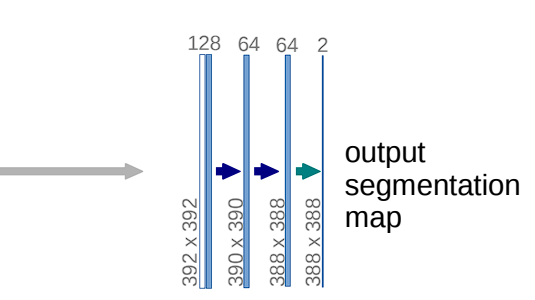

## Strategy

At this stage, we already have:

- Decoder output: **[64, 392, 392]**
- Corresponding encoder feature map: **[64, 568, 568]**

The encoder feature map will first be cropped to match the spatial dimensions of the decoder output. Afterward, both tensors will be concatenated along the channel dimension via the final skip connection.

### Expected Transformation

```text
Encoder Feature Map (cropped): [64, 392, 392]
Decoder Output: [64, 392, 392] -> Concatenation --> [128, 392, 392]
```

Therefore, the final skip connection should produce a tensor with shape:

```text
[128, 392, 392]
```

In [15]:
# Verification:
skip_connection = SkipConnection(config["ImageCropper"])
dec_output = skip_connection(encoder.uncropped_tensor_list[0], dec_output)

## OutputSegmentationMap Class

### 1×1 Convolution

Instead of flattening the feature map and using Fully Connected (Linear) layers, U-Net uses a 1×1 convolution as the final layer.

This allows the network to:

- Preserve the spatial structure of the image.
- Perform pixel-wise classification.
- Reduce the number of feature channels to the required number of output classes.
- Handle images of different sizes without requiring a fixed input dimension.

Example:

[64, 388, 388]
        ↓ 1×1 Conv
[2, 388, 388]

where `2` represents the number of segmentation classes.

In [16]:
class OutputSegmentationMap(nn.Module):
    def __init__(self,
                in_channels: int,
                out_channels: int = config["n_classes"],
                hidden_channels: int = config["segmentation_map_hidden_channels"],
                kernel_size: int = config["segmentation_map_kernel_size"]):
        super(OutputSegmentationMap, self).__init__()
        conv_1 = nn.Conv2d(
            in_channels = in_channels,
            out_channels = hidden_channels,
            kernel_size = config["kernel_size_E"],
            padding = config["padding_E"],
        )
        conv_2 = nn.Conv2d(
            in_channels = hidden_channels,
            out_channels = hidden_channels,
            kernel_size = config["kernel_size_E"],
            padding = config["padding_E"],
        )
        
        # 1x1 Conv: Instead of using Fully Connected Linear Layers, we are using 1 x 1 convolution layer
        conv_3 = nn.Conv2d(
            in_channels = hidden_channels,
            out_channels = out_channels,
            kernel_size = kernel_size,
            padding = config["padding_E"],
        )

        self.layers = nn.Sequential(
            conv_1, conv_2, conv_3
        )
        
    def forward(self, x: torch.Tensor):
        return self.layers(x)


In [17]:
output_segmentation_map = OutputSegmentationMap(
    dec_output.shape[1]
)
output_segmentation_map(dec_output).shape

torch.Size([1, 2, 388, 388])

---

## Testing with 316 x 316 image size

#### Feeding into the Encoder

In [18]:
# img = torch.rand(1, 1, 128 * 2, 128 * 2) # Matching shape of the input image from the paper: https://arxiv.org/pdf/1505.04597
img = torch.rand(1, 1, 316, 316) # Matching shape of the input image from the paper: https://arxiv.org/pdf/1505.04597
encoder = Encoder(
    in_channels = img.shape[1]
)
print(f"input image.shape = {img.shape}")
print("-" * 70)
enc_img = encoder(img) # Get the output from the encoder; (ignoring the skip-connections and cropping for now)
print(f"final output image shape = {enc_img.shape}")
print(f"NOTE: Progressively decreased the image spatial resolution and increased the channel dim")

input image.shape = torch.Size([1, 1, 316, 316])
----------------------------------------------------------------------
final output image shape = torch.Size([1, 512, 16, 16])
NOTE: Progressively decreased the image spatial resolution and increased the channel dim


#### Feeding into the Bottleneck Layer

In [19]:
bottleneck = Bottleneck(
    in_channels = enc_img.shape[1], out_channels = config["skip_connections_channel_B"]
)
enc_img = bottleneck(enc_img)
print(f"Bottleneck output.shape = {enc_img.shape}")

Bottleneck output.shape = torch.Size([1, 512, 24, 24])


#### Feeding into the Decoder

In [20]:
decoder = Decoder(
    enc_img.shape[1]
)
dec_output = decoder(enc_img, encoder.uncropped_tensor_list)
print(f"Decoder input image.shape = {enc_img.shape}")
print(f"final output image shape = {dec_output.shape}")
print(f"NOTE: Progressively increased the image spatial resolution and decreased the channel dim")

Decoder input image.shape = torch.Size([1, 512, 24, 24])
final output image shape = torch.Size([1, 64, 136, 136])
NOTE: Progressively increased the image spatial resolution and decreased the channel dim


#### Feeding into the Segmentation Mask Layer

In [21]:
# Verification:
skip_connection = SkipConnection(config["ImageCropper"])
dec_output = skip_connection(encoder.uncropped_tensor_list[0], dec_output)

In [22]:
output_segmentation_map = OutputSegmentationMap(
    dec_output.shape[1]
)
output_segmentation_map(dec_output).shape

torch.Size([1, 2, 132, 132])

### Getting Total Number of Parameters in this Setting (input image resolution = 316 x 316)

In [23]:
encoder_params = sum(p.numel() for p in encoder.parameters())
bottleneck_params = sum(p.numel() for p in bottleneck.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())
output_segmentation_map_params = sum(
    p.numel() for p in output_segmentation_map.parameters()
)

total_params = (
    encoder_params
    + bottleneck_params
    + decoder_params
    + output_segmentation_map_params
)

print("=" * 60)
print("Model Parameter Statistics")
print("=" * 60)
print(f"{'Encoder':30s}: {encoder_params:>15,}")
print(f"{'Bottleneck':30s}: {bottleneck_params:>15,}")
print(f"{'Decoder':30s}: {decoder_params:>15,}")
print(f"{'Segmentation Head':30s}: {output_segmentation_map_params:>15,}")
print("-" * 60)
print(f"Total Parameters: {total_params:,} ({total_params/1e6:.2f} M)")
print("=" * 60)

Model Parameter Statistics
Encoder                       :       4,684,224
Bottleneck                    :      16,255,488
Decoder                       :       4,216,128
Segmentation Head             :         110,850
------------------------------------------------------------
Total Parameters: 25,266,690 (25.27 M)


## Defining U-Net Model

In [24]:
class UNet(nn.Module):
    """
    Implementation of the U-Net architecture for biomedical image segmentation.

    This model is composed of five major components:

        1. Encoder
        2. Bottleneck
        3. Decoder
        4. Skip Connections
        5. Output Segmentation Map

    The encoder progressively extracts hierarchical features while reducing
    the spatial dimensions of the input image. Intermediate feature maps are
    stored and later reused by the decoder through skip connections.

    The bottleneck acts as a bridge between the encoder and decoder. In this
    implementation, the bottleneck performs feature extraction followed by an
    upsampling operation before passing the resulting feature map to the decoder.

    The decoder reconstructs spatial information through a series of convolution
    and upsampling operations. At each stage, skip connections concatenate
    cropped encoder feature maps with decoder feature maps, helping preserve
    fine-grained localization information that would otherwise be lost during
    downsampling.

    The final OutputSegmentationMap module applies two convolution layers
    followed by a 1×1 convolution to produce pixel-wise class predictions for
    semantic segmentation.

    Architecture:
        Input Image
            ↓
        Encoder
            ↓
        Bottleneck
            ↓
        Skip Connections
            ↓
        Decoder
            ↓
    Output Segmentation Map

    Reference:
        Paper: U-Net: Convolutional Networks for Biomedical Image Segmentation
        Link : https://arxiv.org/pdf/1505.04597

    Author:
        Himanshu Singh
        Research Engineer | 2026

    Implementation based on:
        U-Net: Convolutional Networks for Biomedical Image Segmentation
    """
    def __init__(self,
        # ---------------------- Encoder Settings ----------------------
        in_channels_E: int,
        in_channels_B: int,
        in_channels_D: int,
        in_channels_S: int,
        n_layers_E: int = config["n_layers_E"],
        kernel_size_E: int = config["kernel_size_E"],
        padding_E: int = config["padding_E"],

        # ---------------------- Bottleneck layer Settings ----------------------
        hidden_channels_B: int = config["hidden_channels_B"],
        out_channels_B: int = config["skip_connections_channel_B"],
        kernel_size_B: int = config["kernel_size_B"],
        padding_B: int = config["padding_B"],
        stride_B: int = config["stride_B"],

        # ---------------------- Decoder Settings ----------------------
        kernel_size_D: int = config["kernel_size_D"],
        padding_D: int = config["padding_D"],
        n_layers_D: int = config["n_layers_D"],
        
        # ---------------------- SkipConnection Settings ----------------------
        img_cropper: ImageCropper = config["ImageCropper"],

        # ---------------------- OutputSegmentationMap Settings ----------------------
        out_channels_S: int = config["n_classes"],
        hidden_channels_S: int = config["segmentation_map_hidden_channels"],
        kernel_size_S: int = config["segmentation_map_kernel_size"]):

        super(UNet, self).__init__()

        # Create encoder
        self.encoder = Encoder(
            in_channels = in_channels_E,
            n_layers = n_layers_E,
            kernel_size = kernel_size_E,
            padding = padding_E
        )

        # Create Bottleneck layer
        self.bottleneck_layer = Bottleneck(
            in_channels = in_channels_B,
            hidden_channels = hidden_channels_B,
            out_channels = out_channels_B,
            kernel_size = kernel_size_B,
            padding = padding_B,
            stride = stride_B
        )

        # Create Decoder
        self.decoder = Decoder(
            in_channels = in_channels_D,
            kernel_size = kernel_size_D,
            padding = padding_D,
            n_layers = n_layers_D
        )

        # Create Skip-connections
        self.skip_connection = SkipConnection(
            ImageCropper = img_cropper
        )

        # Create OutputSegmentationMap layer
        self.segmentation_map = OutputSegmentationMap(
            in_channels = in_channels_S,
            hidden_channels = hidden_channels_S,
            out_channels = out_channels_S,
            kernel_size = kernel_size_S
        )
        
    def forward(self, x: torch.Tensor):
        enc_images = self.encoder(x)
        bottleneck_output = self.bottleneck_layer(enc_images)
        decoder_output = self.decoder(bottleneck_output, self.encoder.uncropped_tensor_list)
        
        # Apply skip connections to the last tensor of the Decoder output
        return self.segmentation_map(self.skip_connection(self.encoder.uncropped_tensor_list[0], decoder_output))

## Standard Metrics

In [25]:
def iou(pred, target, eps=1e-6):
    pred = pred.bool()
    target = target.bool()

    intersection = (pred & target).sum()
    union = (pred | target).sum()

    return (intersection + eps) / (union + eps)

In [26]:
def dice(pred, target, eps=1e-6):
    pred = pred.float()
    target = target.float()

    intersection = (pred * target).sum()

    return (2 * intersection + eps) / (
        pred.sum() + target.sum() + eps
    )

In [27]:
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    correct = (pred == target).sum()
    total = target.numel()
    return correct.float() / total

## Get the Training Data and Visualize them

In [28]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
import torch
import numpy as np


class OxfordPetSegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_paths = sorted(
            Path(image_dir).glob("*.jpg")
        )

        self.mask_paths = [
            Path(mask_dir) / f"{image_path.stem}.png"
            for image_path in self.image_paths
        ]

        self.image_transform = transforms.Compose([
            transforms.Resize((config["img_H"], config["img_W"])),
            transforms.ToTensor()
        ])

        # because the mask shapes are variable and i want to match the size of my U-net model's output
        self.mask_transform = transforms.Resize(
            (config["mask_img_H"], config["mask_img_W"]),
            interpolation=transforms.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("L")

        mask = Image.open(
            self.mask_paths[idx]
        )

        image = self.image_transform(image)
        mask = self.mask_transform(mask)

        # Pet vs Background: converting it to a binary classification problem
        mask = torch.from_numpy(
            (np.array(mask) == 1).astype(np.int64)
        )

        return image, mask

In [29]:
from torch.utils.data import DataLoader

dataset = OxfordPetSegmentationDataset(
    image_dir = config["image_dir"],
    mask_dir = config["mask_dir"]
)
image, mask = dataset[0]
print(image.shape)
print(mask.shape)

torch.Size([1, 316, 316])
torch.Size([132, 132])


## Visualization Scripts

In [43]:
import random
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def visualize_predictions(
    model,
    dataset,
    device,
    n_samples=3
):
    model.eval()

    random_indices = random.sample(
        range(len(dataset)),
        k=min(n_samples, len(dataset))
    )

    fig, axes = plt.subplots(
        len(random_indices),
        3,
        figsize=(12, 4 * len(random_indices))
    )

    # Handle n_samples = 1
    if len(random_indices) == 1:
        axes = [axes]

    for row, idx in enumerate(random_indices):

        image, mask = dataset[idx]

        image_batch = image.unsqueeze(0).to(device)

        pred = model(image_batch)

        pred = pred.argmax(dim=1).squeeze(0).cpu()

        axes[row][0].imshow(
            image.squeeze(0),
            cmap="gray"
        )
        axes[row][0].set_title(f"Input Image (idx={idx})")
        axes[row][0].axis("off")

        axes[row][1].imshow(
            mask,
            cmap="gray"
        )
        axes[row][1].set_title("Ground Truth")
        axes[row][1].axis("off")

        axes[row][2].imshow(
            pred,
            cmap="gray"
        )
        axes[row][2].set_title("Prediction")
        axes[row][2].axis("off")

    plt.tight_layout()

    model.train()

    return fig

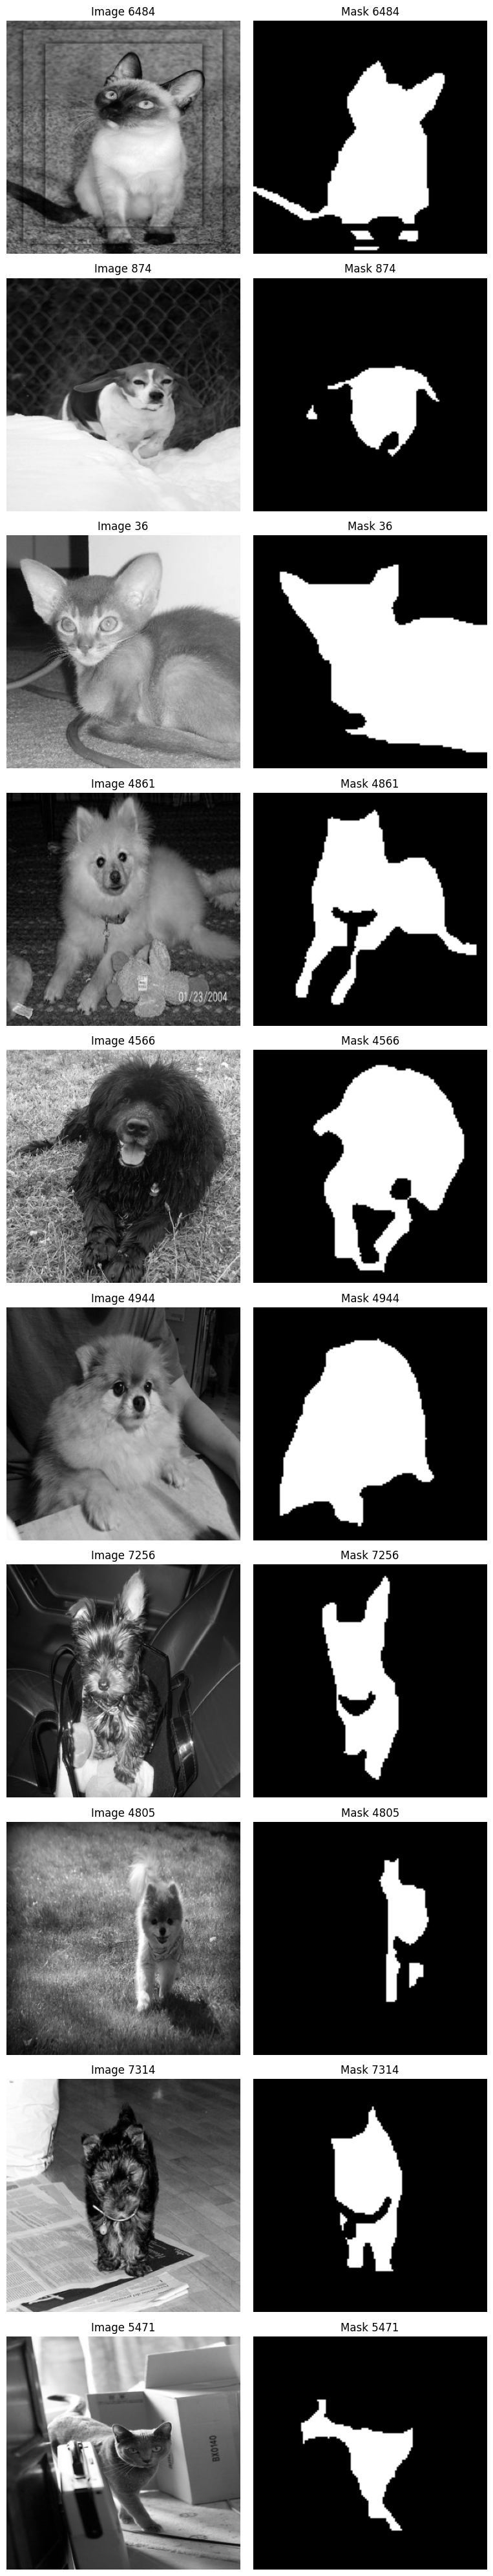

In [ ]:
import random
import matplotlib.pyplot as plt

def visualize_dataset():
    indices = random.sample(range(len(dataset)), 10)

    fig, axes = plt.subplots(10, 2, figsize=(8, 40))

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]

        # Convert image from [C,H,W] -> [H,W,C]
        image = image.permute(1, 2, 0)

        axes[row, 0].imshow(image.squeeze(0), cmap="gray")
        axes[row, 0].set_title(f"Image {idx}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title(f"Mask {idx}")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()
visualize_dataset()

In [32]:
print(f"image.min() = {image.min()} | image.max() = {image.max()}")
print(f"mask.unique() = {mask.unique()} [Task: Binary classification]")

image.min() = 0.0117647061124444 | image.max() = 0.9019607901573181
mask.unique() = tensor([0, 1]) [Task: Binary classification]


## Experiment Tracking

In [33]:
# weights and bias for experiment tracking
import wandb

wandb.init(
    project="unet-oxford-pets",
    name="unet-from-scratch",
    config={
        "epochs": config["epochs"],
        "batch_size": config["batch_size"],
        "optimizer": config["optimizer"],
        "architecture": "U-Net"
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Himanshu Singh\_netrc.
wandb: Currently logged in as: himanshusr451tehs (himanshusr451tehs-personaluse-com) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Proper Weigth initialization

#### because I'm not using any BatchNorm because Original U-Net dsn't had this Architecture so i need better weights initialization

In [34]:
import torch.nn as nn

def initialize_weights(module):

    if isinstance(module, nn.Conv2d):

        nn.init.kaiming_normal_(
            module.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        if module.bias is not None:
            nn.init.constant_(
                module.bias,
                0
            )

    elif isinstance(module, nn.ConvTranspose2d):

        nn.init.kaiming_normal_(
            module.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        if module.bias is not None:
            nn.init.constant_(
                module.bias,
                0
            )

## Get the model ready

In [35]:
model = UNet(
    in_channels_E = config["in_channels_E"],
    in_channels_B = config["in_channels_B"],
    in_channels_D = config["in_channels_D"],
    in_channels_S = config["in_channels_S"]
)
model.apply(initialize_weights)

UNet(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): EncoderBlock(
        (relu): ReLU()
        (conv_1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
        (conv_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): EncoderBlock(
        (relu): ReLU()
        (conv_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
        (conv_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): EncoderBlock(
        (relu): ReLU()
        (conv_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
        (conv_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (3): EncoderBlock(
        (relu): ReLU()
        (conv_1): Conv2d(256, 

## Prepare Dataloader for Training the Model

In [36]:
import torch
# Create a DataLoader for training with batch_size = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader = DataLoader(
    dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

## Saving and Loading Scripts

In [37]:
def save_checkpoint(
    model,
    optimizer,
    epoch,
    loss,
    save_path
):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": loss
        },
        save_path
    )

In [38]:
def optimizer_to(optimizer, device):

    for state in optimizer.state.values():

        for k, v in state.items():

            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)

def load_checkpoint(model, optimizer, saved_model_path):
    checkpoint = torch.load(
        saved_model_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    optimizer_to(
        optimizer,
        device
    )

    start_epoch = checkpoint["epoch"]

    loss = checkpoint["loss"]
    return model, optimizer, start_epoch, loss

## Training Loop

In [39]:
# import torch
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# def train_model(model: UNet,
#             optimizer: torch.optim.Adam,
#             device: torch.device,
#             loader,
#             epochs: int = config["epochs"],
#             ):
#     loss_fn = nn.CrossEntropyLoss()
#     model = model.to(device)
#     for epoch in range(epochs):
#         indices = random.sample(range(len(dataset)), config["batch_size"])
#         image, mask = dataset[indices]
#         image = image.to(device)
#         mask = mask.to(device)
#         pred_mask = model(image)
#         loss = loss_fn(
#             pred_mask, mask.squeeze(0).long()
#         )
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         if epoch % 10 == 0:
#             print(f"Loss = {loss:.4f}")

In [40]:
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import wandb


def train_model(
    model: UNet,
    optimizer: torch.optim.Adam,
    train_loader: DataLoader,
    device: torch.device,
    epochs: int = config["epochs"],
    start_epoch = 0
):
    print(f"Training the Model on device = [{device}]")

    model = model.to(device)
    wandb.watch(
        model,
        log="all",
        log_freq=100
    )

    loss_fn = nn.CrossEntropyLoss()

    epoch_bar = tqdm(
        range(start_epoch, epochs),
        desc="Training",
        unit="epoch",
        colour="green"
    )

    for epoch in epoch_bar:

        model.train()

        # ---------------- Epoch Metrics ----------------
        epoch_loss = 0.0
        epoch_acc = 0.0
        epoch_iou = 0.0
        epoch_dice = 0.0
        # ------------------------------------------------

        batch_bar = tqdm(
            train_loader,
            leave=False,
            desc=f"Epoch {epoch + 1}/{epochs}",
            colour="blue"
        )

        for images, masks in batch_bar:

            images = images.to(device)
            masks = masks.to(device)

            # ------------------------------------------------
            # Forward Pass
            # ------------------------------------------------

            pred_masks = model(images)

            loss = loss_fn(
                pred_masks,
                masks.long()
            )

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            pred_classes = pred_masks.argmax(dim=1)

            batch_loss = loss.item()

            batch_acc = pixel_accuracy(
                pred_masks,
                masks
            )

            batch_iou = iou(
                pred_classes,
                masks
            )

            batch_dice = dice(
                pred_classes,
                masks
            )

            # ------------------------------------------------
            # Accumulate Epoch Metrics
            # ------------------------------------------------

            epoch_loss += batch_loss
            epoch_acc += batch_acc.item()
            epoch_iou += batch_iou.item()
            epoch_dice += batch_dice.item()

            # ------------------------------------------------
            # Batch Progress Bar
            # ------------------------------------------------
            p_classes = pred_masks.argmax(dim=1).unique(
                return_counts=True
            )
            batch_bar.set_postfix(
                loss=f"{batch_loss:.4f}",
                dice=f"{batch_dice:.4f}",
                iou=f"{batch_iou:.4f}",
                pred_classes = f"{p_classes}"
            )

        # ==================================================
        # Epoch Metrics
        # ==================================================

        epoch_loss /= len(train_loader)
        epoch_acc /= len(train_loader)
        epoch_iou /= len(train_loader)
        epoch_dice /= len(train_loader)

        # ==================================================
        # W&B Logging
        # ==================================================
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "pixel_accuracy": epoch_acc,
            "iou": epoch_iou,
            "dice": epoch_dice,
            "learning_rate": optimizer.param_groups[0]["lr"]
        })

        # ==================================================
        # Epoch Progress Bar
        # ==================================================
        p_classes = pred_masks.argmax(dim=1).unique(
                return_counts=True
            )
        epoch_bar.set_postfix(
            loss=f"{epoch_loss:.4f}",
            acc=f"{epoch_acc:.4f}",
            dice=f"{epoch_dice:.4f}",
            iou=f"{epoch_iou:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            p_classes = f"{p_classes}"
        )

        # ==================================================
        # Visualization Every 1 Epochs
        # ==================================================

        if epoch % 1 == 0:

            # Save the checkpoint
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=epoch + 1,
                loss=epoch_loss,
                save_path=f"checkpoints/unet_epoch_{epoch+1}.pth"
            )

            fig = visualize_predictions(
                model=model,
                dataset=dataset,
                device=device
            )
            fig.canvas.draw()

            img = np.array(
                fig.canvas.renderer.buffer_rgba()
            )
            # wandb.log({
            #     "predictions": wandb.Image(
            #         img,
            #         caption=f"Epoch {epoch + 1}"
            #     )
            # })

            plt.close(fig)
        if epoch == 0:
            print(
                f"batch_loss = {batch_loss:.4f}"
            )

        # ==================================================
        # Console Logging
        # ==================================================
        
        print(
            f"[Epoch {epoch+1:03d}/{epochs}] "
            f"Loss={epoch_loss:.4f} "
            f"Acc={epoch_acc:.4f} "
            f"Dice={epoch_dice:.4f} "
            f"IoU={epoch_iou:.4f}"
        )
        print(
            pred_masks.argmax(dim=1).unique(
                return_counts=True
            )
        )

    print(
        f"\nTraining Finished | Final Loss = {epoch_loss:.4f}"
    )
    wandb.finish()

## Train the model

In [41]:
if config["optimizer"].lower() == "adam":
    optimizer = torch.optim.Adam(params = model.parameters(), lr = config["lr"])

# model, optimizer, start_epoch, loss = load_checkpoint(
#     model = model,
#     optimizer = optimizer,
#     saved_model_path = "checkpoints/unet_epoch_16.pth"
# )
train_model(model = model, optimizer = optimizer, device = device, train_loader = train_loader, start_epoch = 0)


Training the Model on device = [cuda]


Training:   0%|          | 0/80 [00:00<?, ?epoch/s]

Epoch 1/80:   0%|          | 0/7390 [00:00<?, ?it/s]

batch_loss = 0.7395
[Epoch 001/80] Loss=0.6101 Acc=0.6996 Dice=0.0045 IoU=0.0039
(tensor([0], device='cuda:0'), tensor([17424], device='cuda:0'))


Epoch 2/80:   0%|          | 0/7390 [00:00<?, ?it/s]

...

[Epoch 058/80] Loss=0.0948 Acc=0.9598 Dice=0.9077 IoU=0.8374
(tensor([0, 1], device='cuda:0'), tensor([14464,  2960], device='cuda:0'))


Epoch 59/80:   0%|          | 0/7390 [00:00<?, ?it/s]

[Epoch 059/80] Loss=0.0937 Acc=0.9602 Dice=0.9095 IoU=0.8396
(tensor([0, 1], device='cuda:0'), tensor([13994,  3430], device='cuda:0'))


Epoch 60/80:   0%|          | 0/7390 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
## Todos:
# 1. Initialize Proper Weights because not using BatchNorm [Done]
# 2. Experiment Tracking [Done]
# 3. End-to-End Traking loop (1. Dataloader, 2. tqdm, 3. experiment tracking) [Done]
# 4. Checkpoint saving of the model while training [Done]
# 5. Saving and Loading Script 

### Testing the Model on Test Data

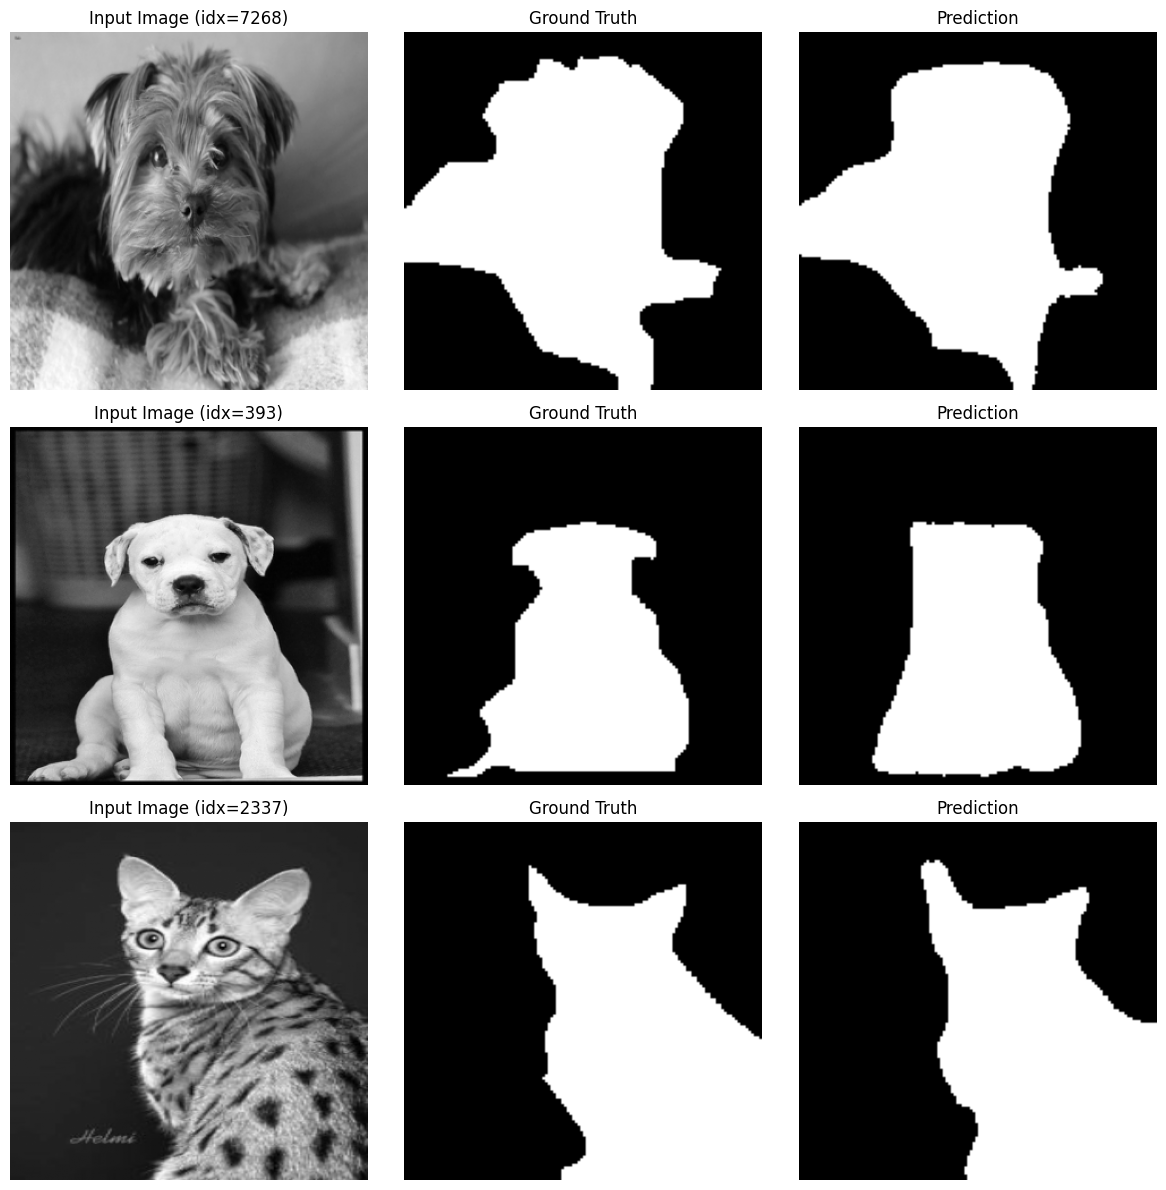

In [62]:
fig = visualize_predictions(
                model=model,
                dataset=dataset,
                device=device
            )
fig.canvas.draw()

### Testing the Model on unseen Data

In [53]:
from PIL import Image
import torchvision.transforms as transforms

test_transform = transforms.Compose([
    transforms.Resize((config["img_H"], config["img_W"])),
    transforms.ToTensor()
])

image = Image.open("test_image_02.png").convert("L")
image_tensor = test_transform(image)
print(image_tensor.shape)
image_batch = image_tensor.unsqueeze(0).to(device)
print(image_batch.shape)

torch.Size([1, 316, 316])
torch.Size([1, 1, 316, 316])


In [54]:
model.eval()
with torch.no_grad():
    logits = model(image_batch)
print(logits.shape)

torch.Size([1, 2, 132, 132])


In [55]:
pred_mask = logits.argmax(dim=1)
print(pred_mask.shape)
pred_mask = pred_mask.squeeze(0).cpu()

torch.Size([1, 132, 132])


In [68]:
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def predict_test_folder(
    folder_path,
    model,
    device
):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize(
            (config["img_H"], config["img_W"])
        ),
        transforms.ToTensor()
    ])

    image_paths = sorted(
        Path(folder_path).glob("*.png")
    )

    for image_path in image_paths:

        image = Image.open(
            image_path
        ).convert("L")

        image_tensor = transform(image)

        image_batch = image_tensor.unsqueeze(0).to(device)

        logits = model(image_batch)

        pred_mask = logits.argmax(dim=1).squeeze(0).cpu()

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(8, 4)
        )

        axes[0].imshow(
            image_tensor.squeeze(0),
            cmap="gray"
        )
        axes[0].set_title(image_path.name)
        axes[0].axis("off")

        axes[1].imshow(
            pred_mask,
            cmap="gray"
        )
        axes[1].set_title("Prediction")
        axes[1].axis("off")

        plt.show()

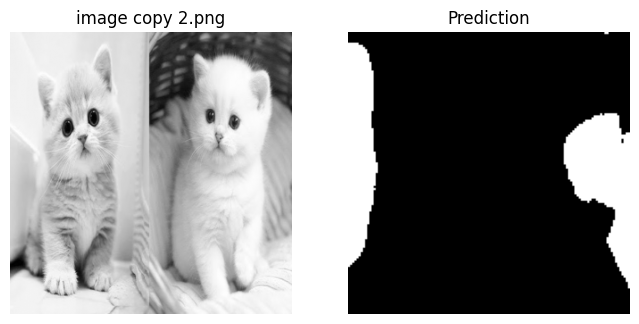

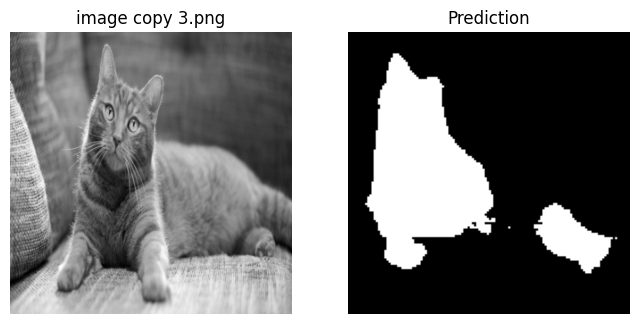

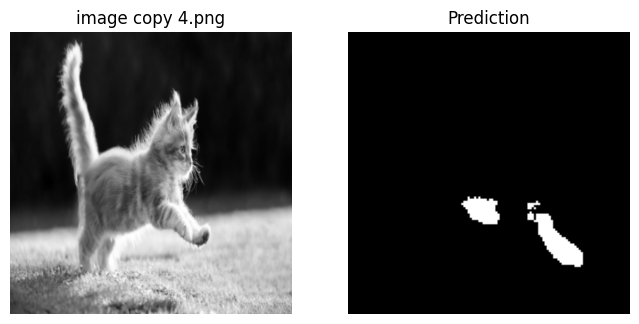

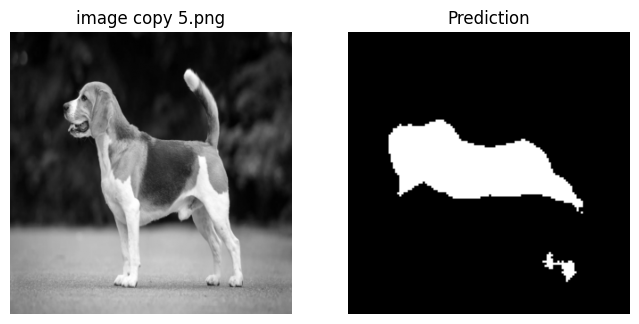

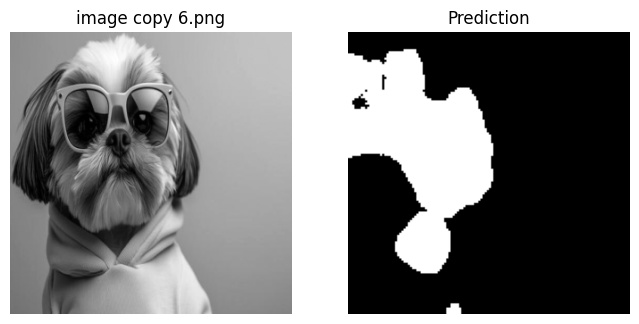

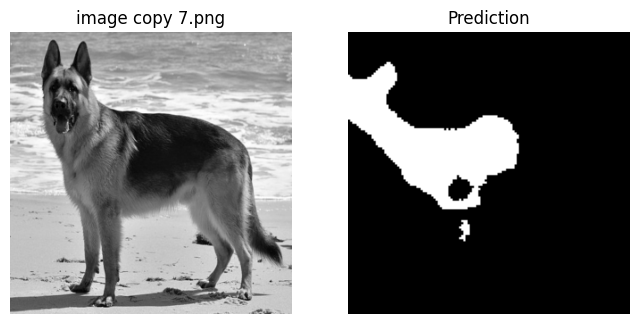

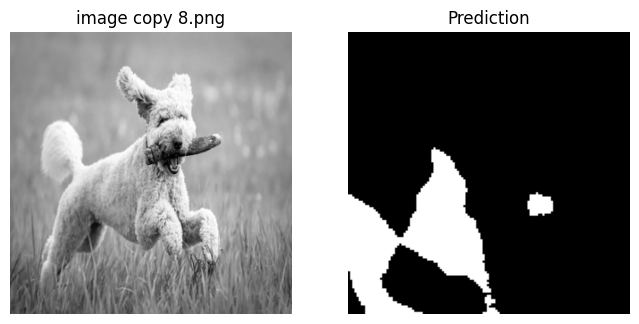

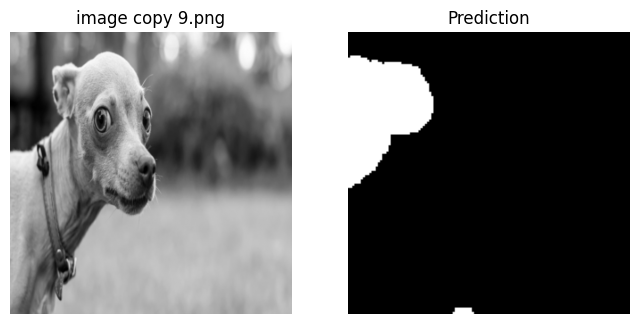

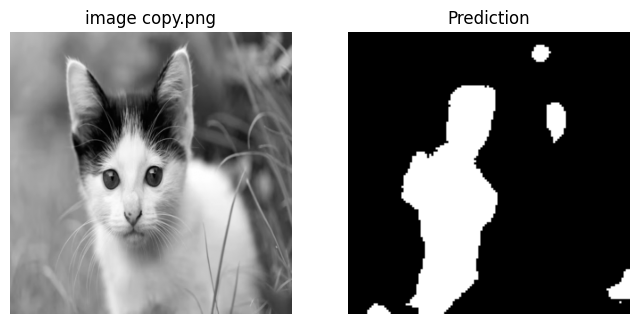

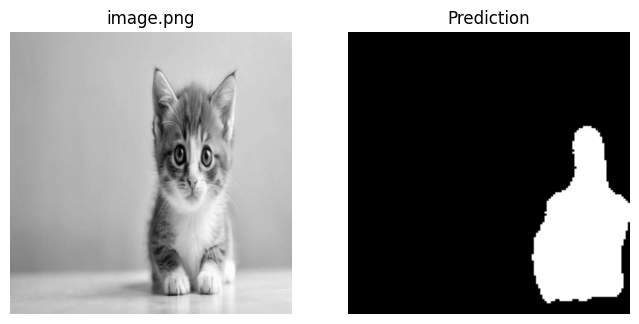

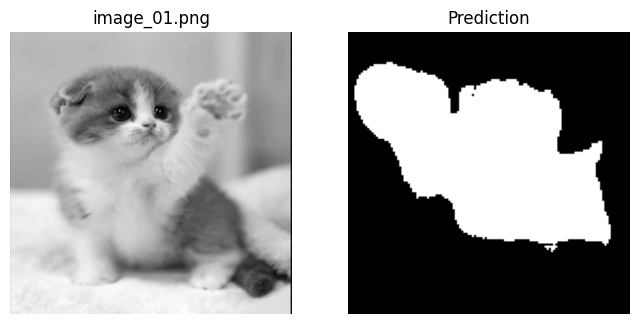

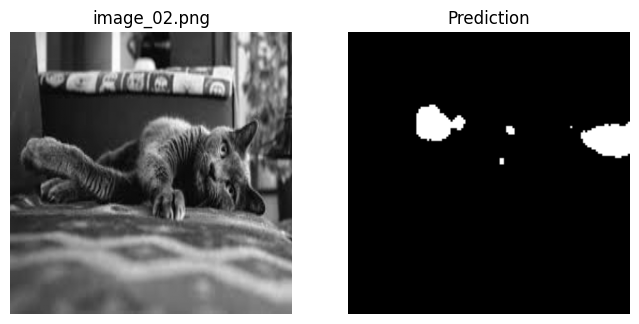

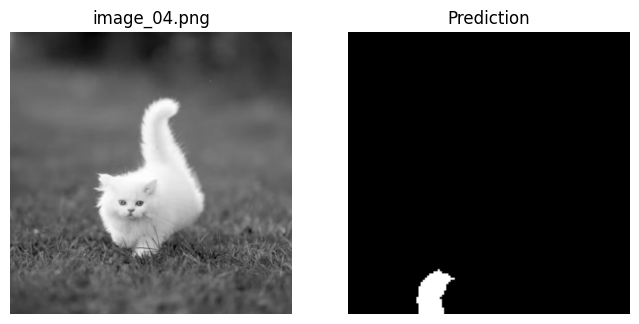

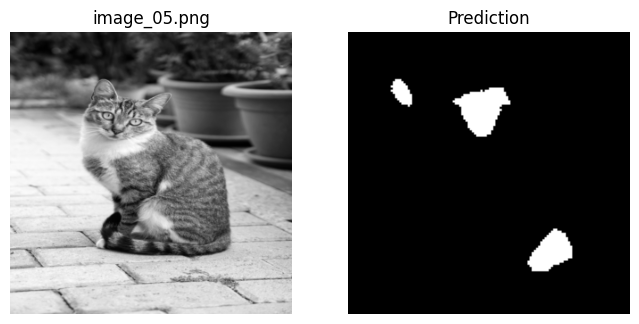

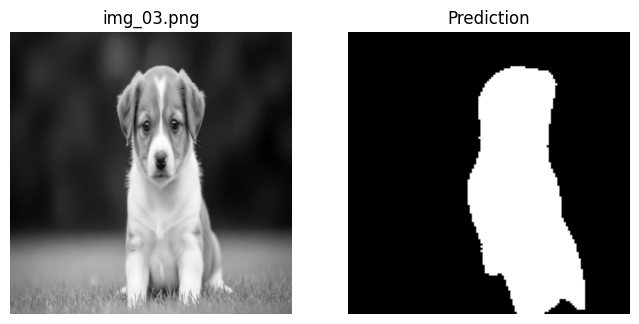

In [71]:
predict_test_folder(
    folder_path="test_images",
    model=model,
    device=device
)